# Notebook 04: Evaluation and Grad-CAM Visualisation

**Project:** Deep Learning-Based Pneumonia Classification from Chest Radiographs with Grad-CAM Interpretability  
**Author:** Viet Thang Tran | L00196203 | Atlantic Technological University

---

## Purpose

This notebook evaluates the three trained models on the held-out test set and applies
Gradient-weighted Class Activation Mapping (Grad-CAM) to interpret model decisions.

## Sections

1. Load trained model checkpoints
2. Compute test set metrics (Accuracy, Precision, Recall, F1, AUC-ROC)
3. Plot confusion matrices and ROC curves
4. Generate Grad-CAM heatmaps for representative cases

## Output Figures

```
outputs/figures/
    fig7_resnet_50_confusion_matrix.png
    fig8_resnet_50_roc_curve.png
    fig9_densenet_121_confusion_matrix.png
    fig10_densenet_121_roc_curve.png
    fig11_efficientnet_b0_confusion_matrix.png
    fig12_efficientnet_b0_roc_curve.png
    fig13_gradcam_comparison.png
```

> **Prerequisite:** Run notebooks 00, 02, and 03 before running this notebook.

## 1. Imports

In [1]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from PIL import Image

import sys
sys.path.append('..')

from src.evaluate import evaluate, print_results
from src.dataset  import get_dataloaders
from src.models   import get_model
from src.gradcam  import GradCAM

plt.rcParams['figure.dpi'] = 300

## 2. Paths and DataLoaders

In [2]:
MODELS_DIR    = os.path.join('..', 'outputs', 'models')
PROCESSED_DIR = os.path.join('..', 'data', 'processed')
FIGURES_DIR   = os.path.join('..', 'outputs', 'figures')

os.makedirs(FIGURES_DIR, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

train_loader, val_loader, test_loader = get_dataloaders(PROCESSED_DIR)
print(f"Test set size: {len(test_loader.dataset)} images")

Using device: cuda
Test set size: 879 images


---

## 3. ResNet-50 Evaluation

### 3.1 Load Checkpoint

In [3]:
model_resnet = get_model('resnet50').to(device)

checkpoint = torch.load(os.path.join(MODELS_DIR, 'resnet_50.pth'), map_location=device)
model_resnet.load_state_dict(checkpoint['model_state_dict'])
model_resnet.eval()

print(f"Loaded ResNet-50 | Best epoch: {checkpoint['epoch']} | Val loss: {checkpoint['val_loss']:.4f}")

Trainable: 22,065,153 / 23,510,081
Loaded ResNet-50 | Best epoch: 6 | Val loss: 0.0291


### 3.2 Compute Metrics

In [4]:
resnet_results = evaluate(model=model_resnet, test_loader=test_loader, device=device)
print_results(resnet_results, 'ResNet-50')


  ResNet-50 Results
  Accuracy:  0.9602
  Precision: 0.9856
  Recall:    0.9594
  F1 Score:  0.9723
  AUC-ROC:   0.9959
  Confusion Matrix:
[[229   9]
 [ 26 615]]



### 3.3 Confusion Matrix

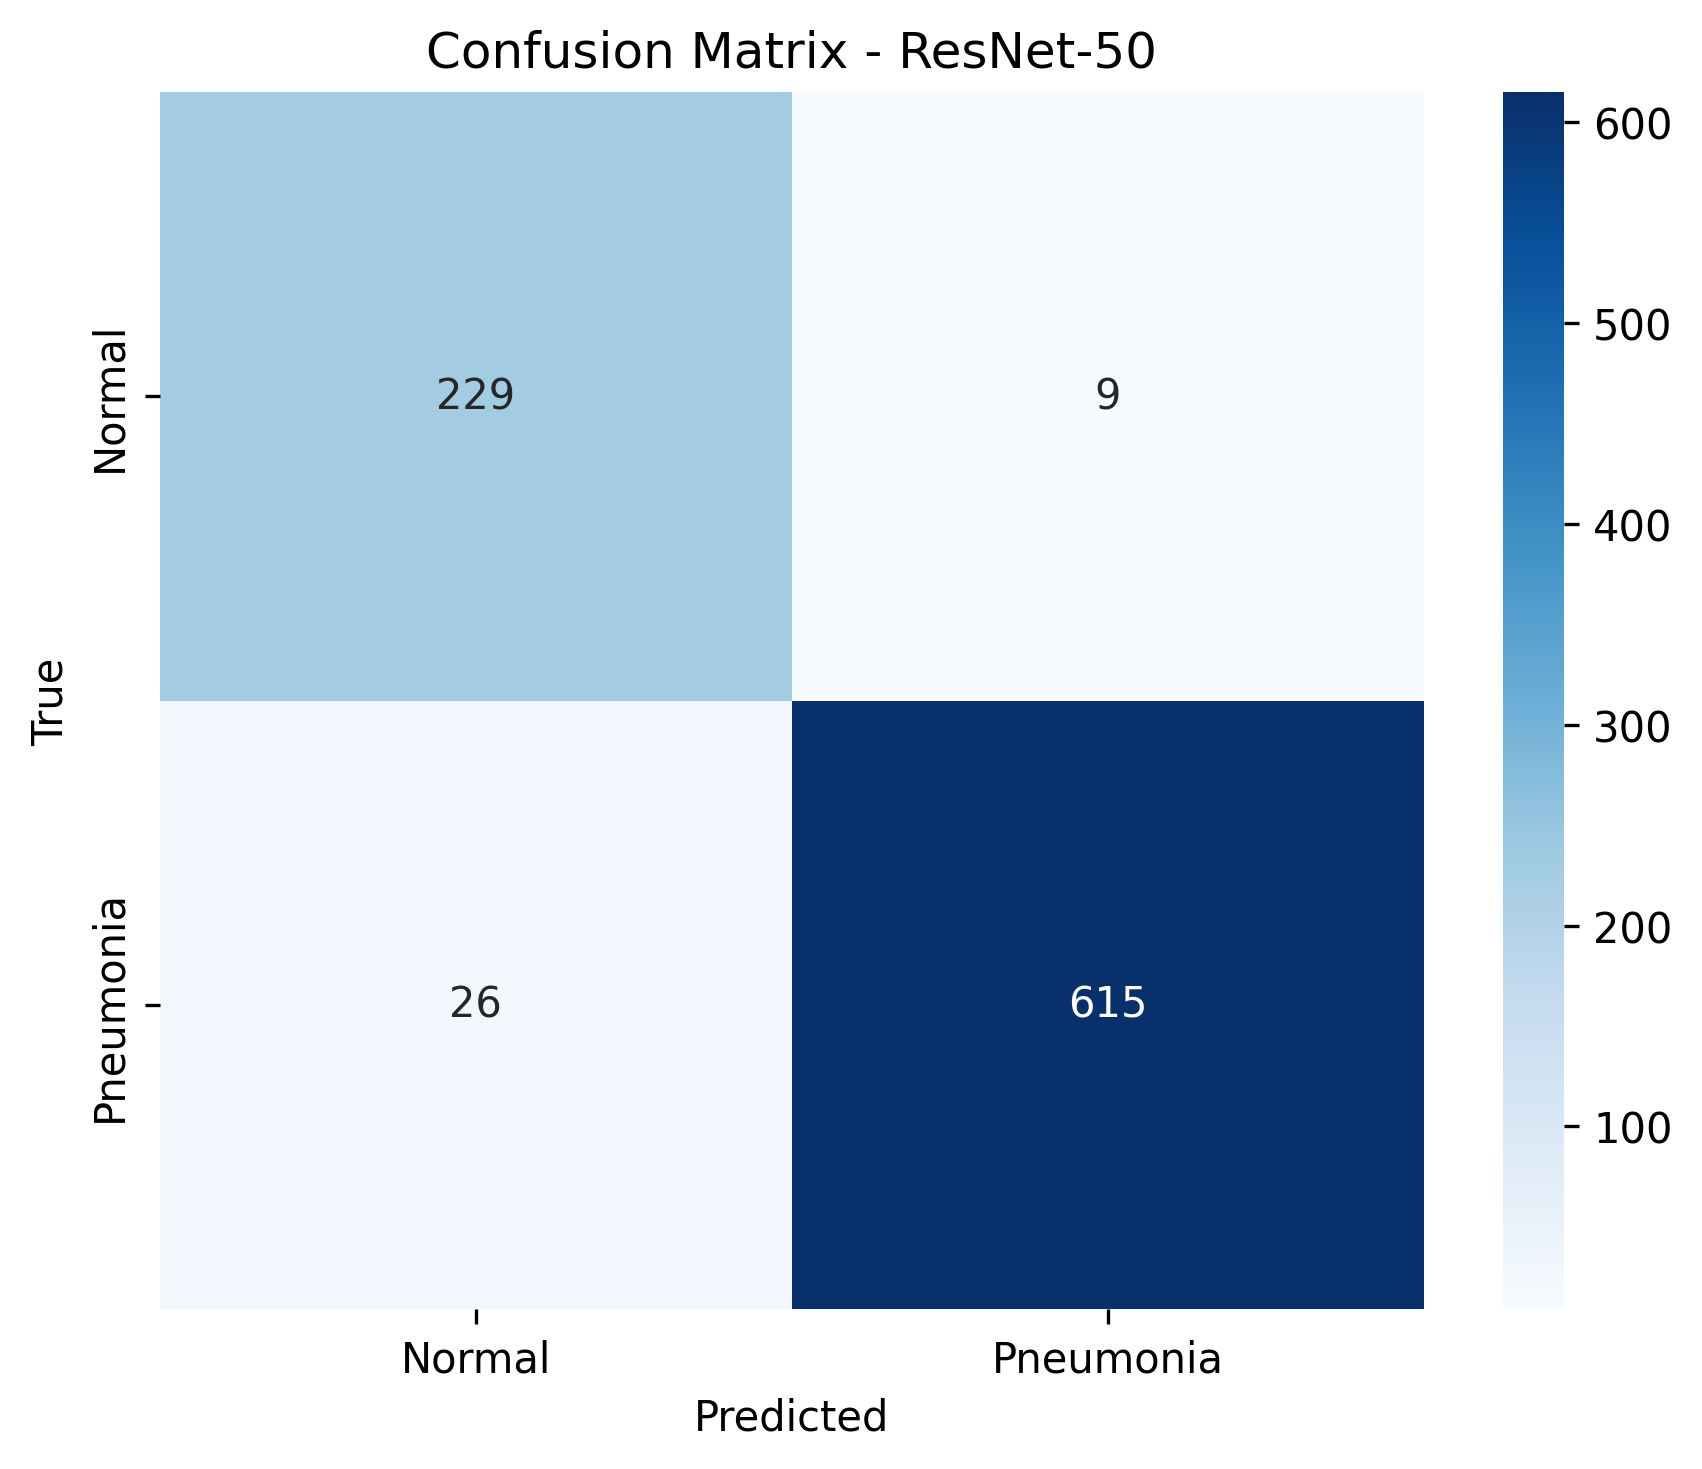

In [5]:
plt.figure(figsize=(6, 5))
sns.heatmap(
    resnet_results['confusion_matrix'],
    annot=True, fmt='d', cmap='Blues',
    xticklabels=['Normal', 'Pneumonia'],
    yticklabels=['Normal', 'Pneumonia']
)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - ResNet-50')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig7_resnet_50_confusion_matrix.png'))
plt.show()

### 3.4 ROC Curve

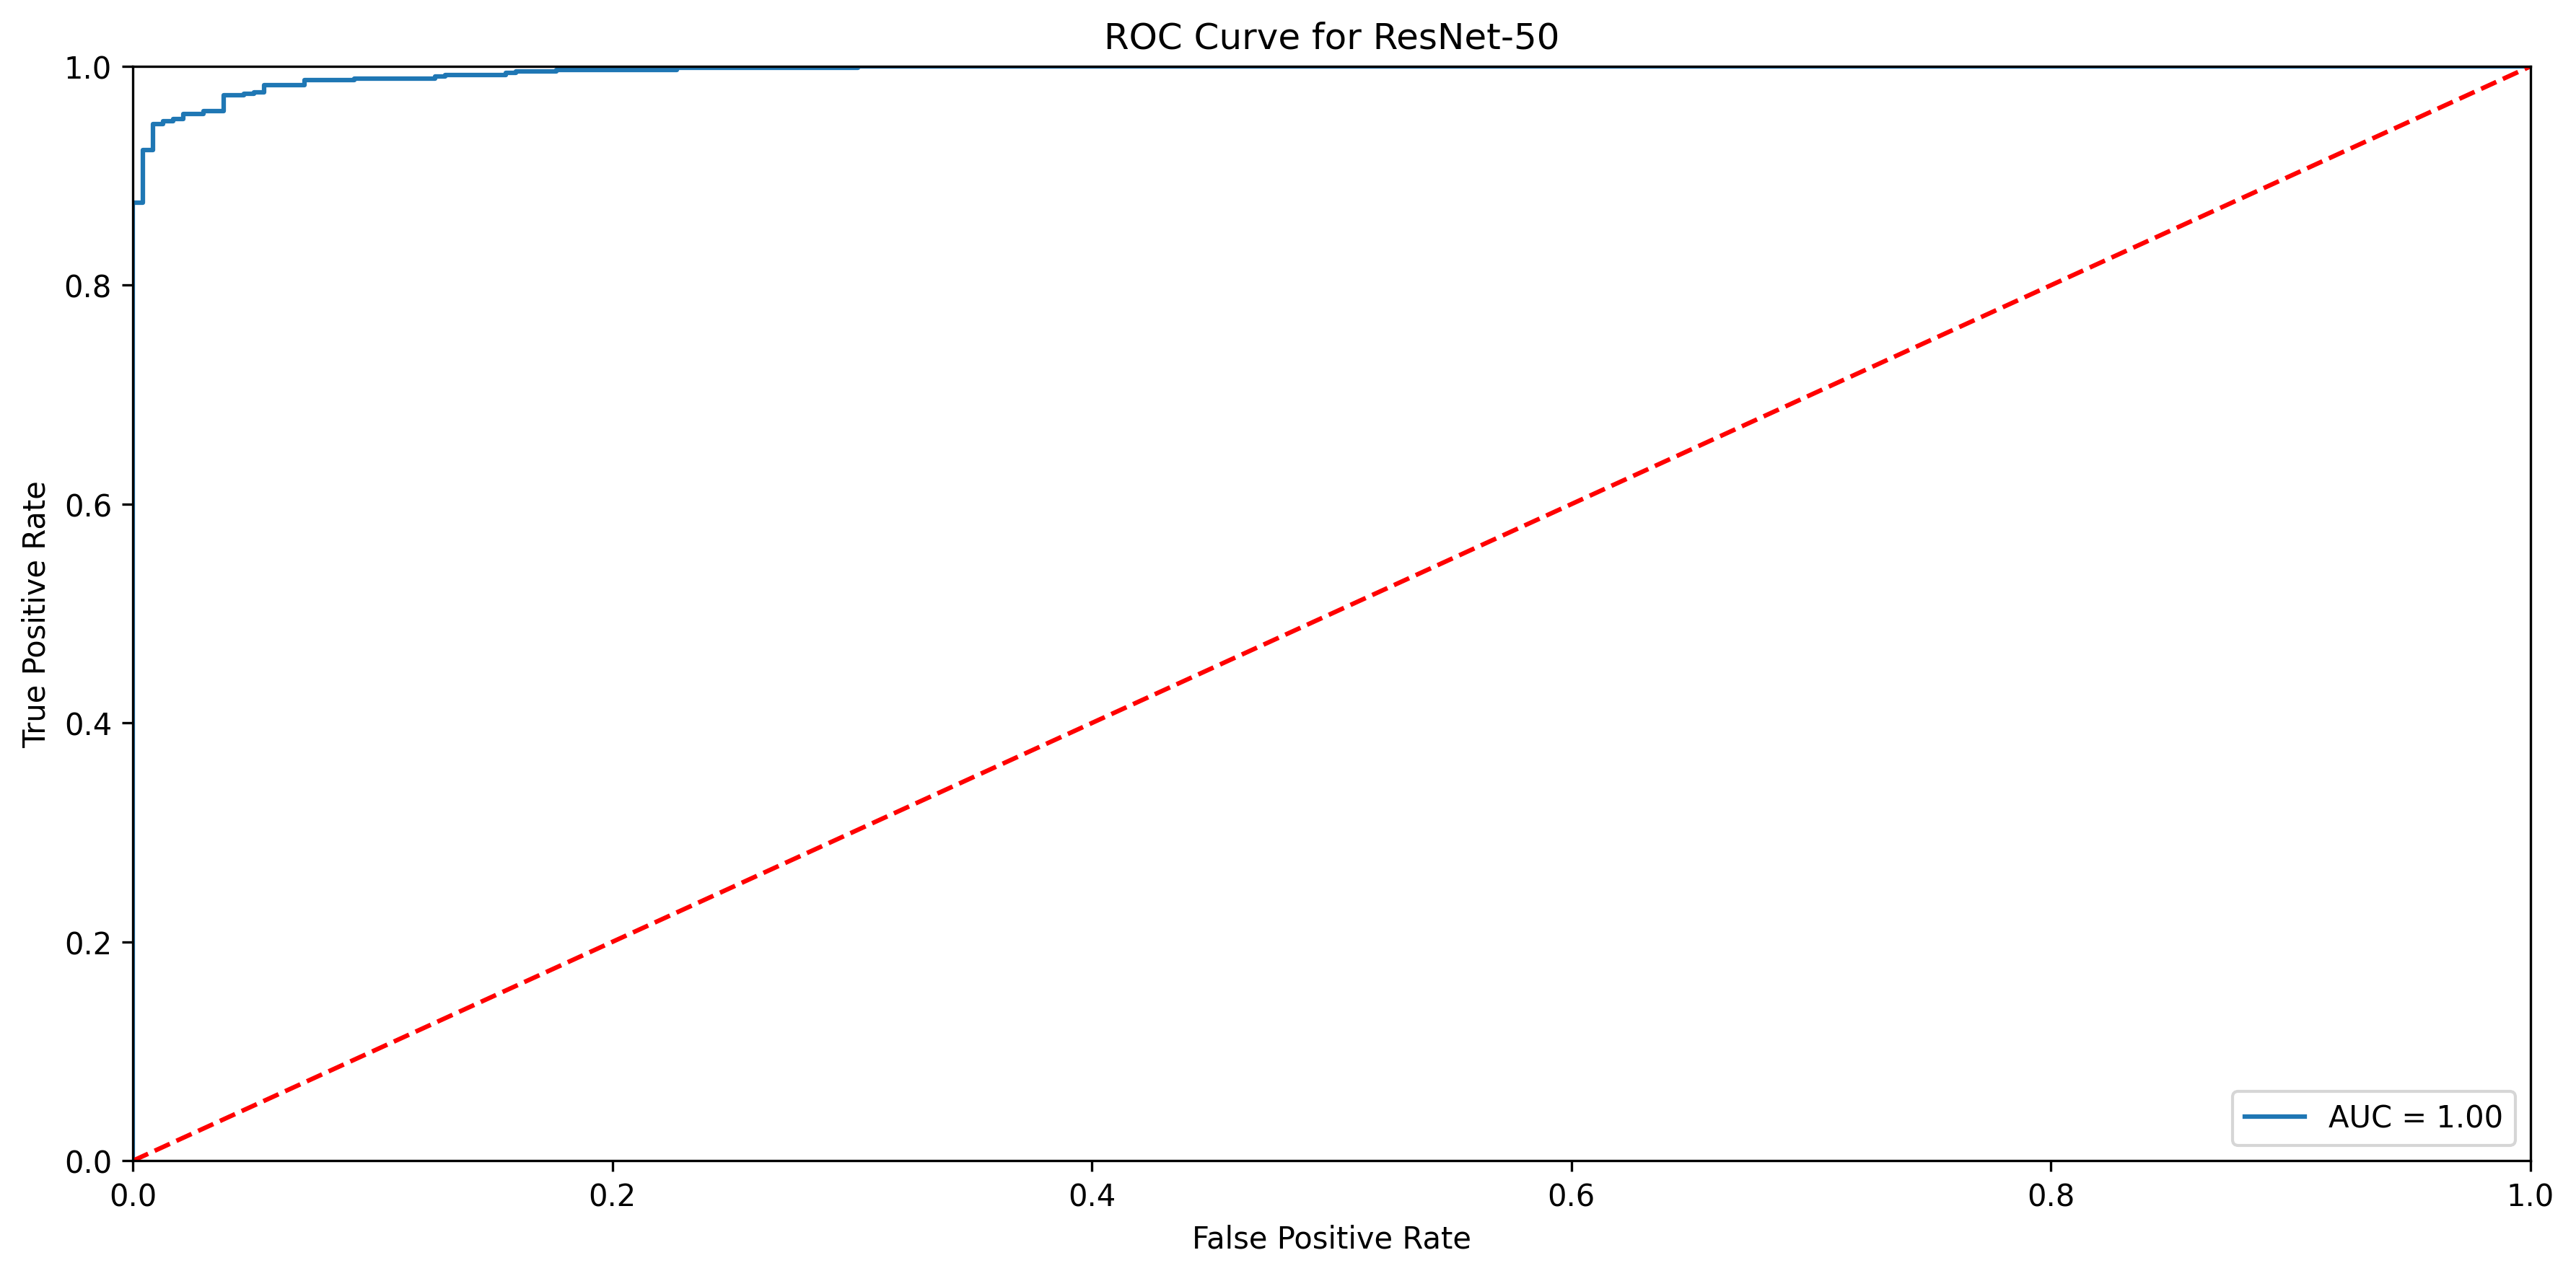

In [6]:
plt.figure(figsize=(12, 6))
plt.plot(
    resnet_results['fpr'], resnet_results['tpr'],
    label=f"AUC = {resnet_results['roc_auc']:.2f}"
)
plt.plot([0, 1], [0, 1], 'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for ResNet-50')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig8_resnet_50_roc_curve.png'))
plt.show()

---

## 4. DenseNet-121 Evaluation

### 4.1 Load Checkpoint

In [7]:
model_densenet = get_model('densenet121').to(device)

checkpoint = torch.load(os.path.join(MODELS_DIR, 'densenet_121.pth'), map_location=device)
model_densenet.load_state_dict(checkpoint['model_state_dict'])
model_densenet.eval()

print(f"Loaded DenseNet-121 | Best epoch: {checkpoint['epoch']} | Val loss: {checkpoint['val_loss']:.4f}")

Trainable: 5,525,249 / 6,954,881
Loaded DenseNet-121 | Best epoch: 8 | Val loss: 0.0316


### 4.2 Compute Metrics

In [8]:
densenet_results = evaluate(model=model_densenet, test_loader=test_loader, device=device)
print_results(densenet_results, 'DenseNet-121')


  DenseNet-121 Results
  Accuracy:  0.9727
  Precision: 0.9874
  Recall:    0.9750
  F1 Score:  0.9812
  AUC-ROC:   0.9973
  Confusion Matrix:
[[230   8]
 [ 16 625]]



### 4.3 Confusion Matrix

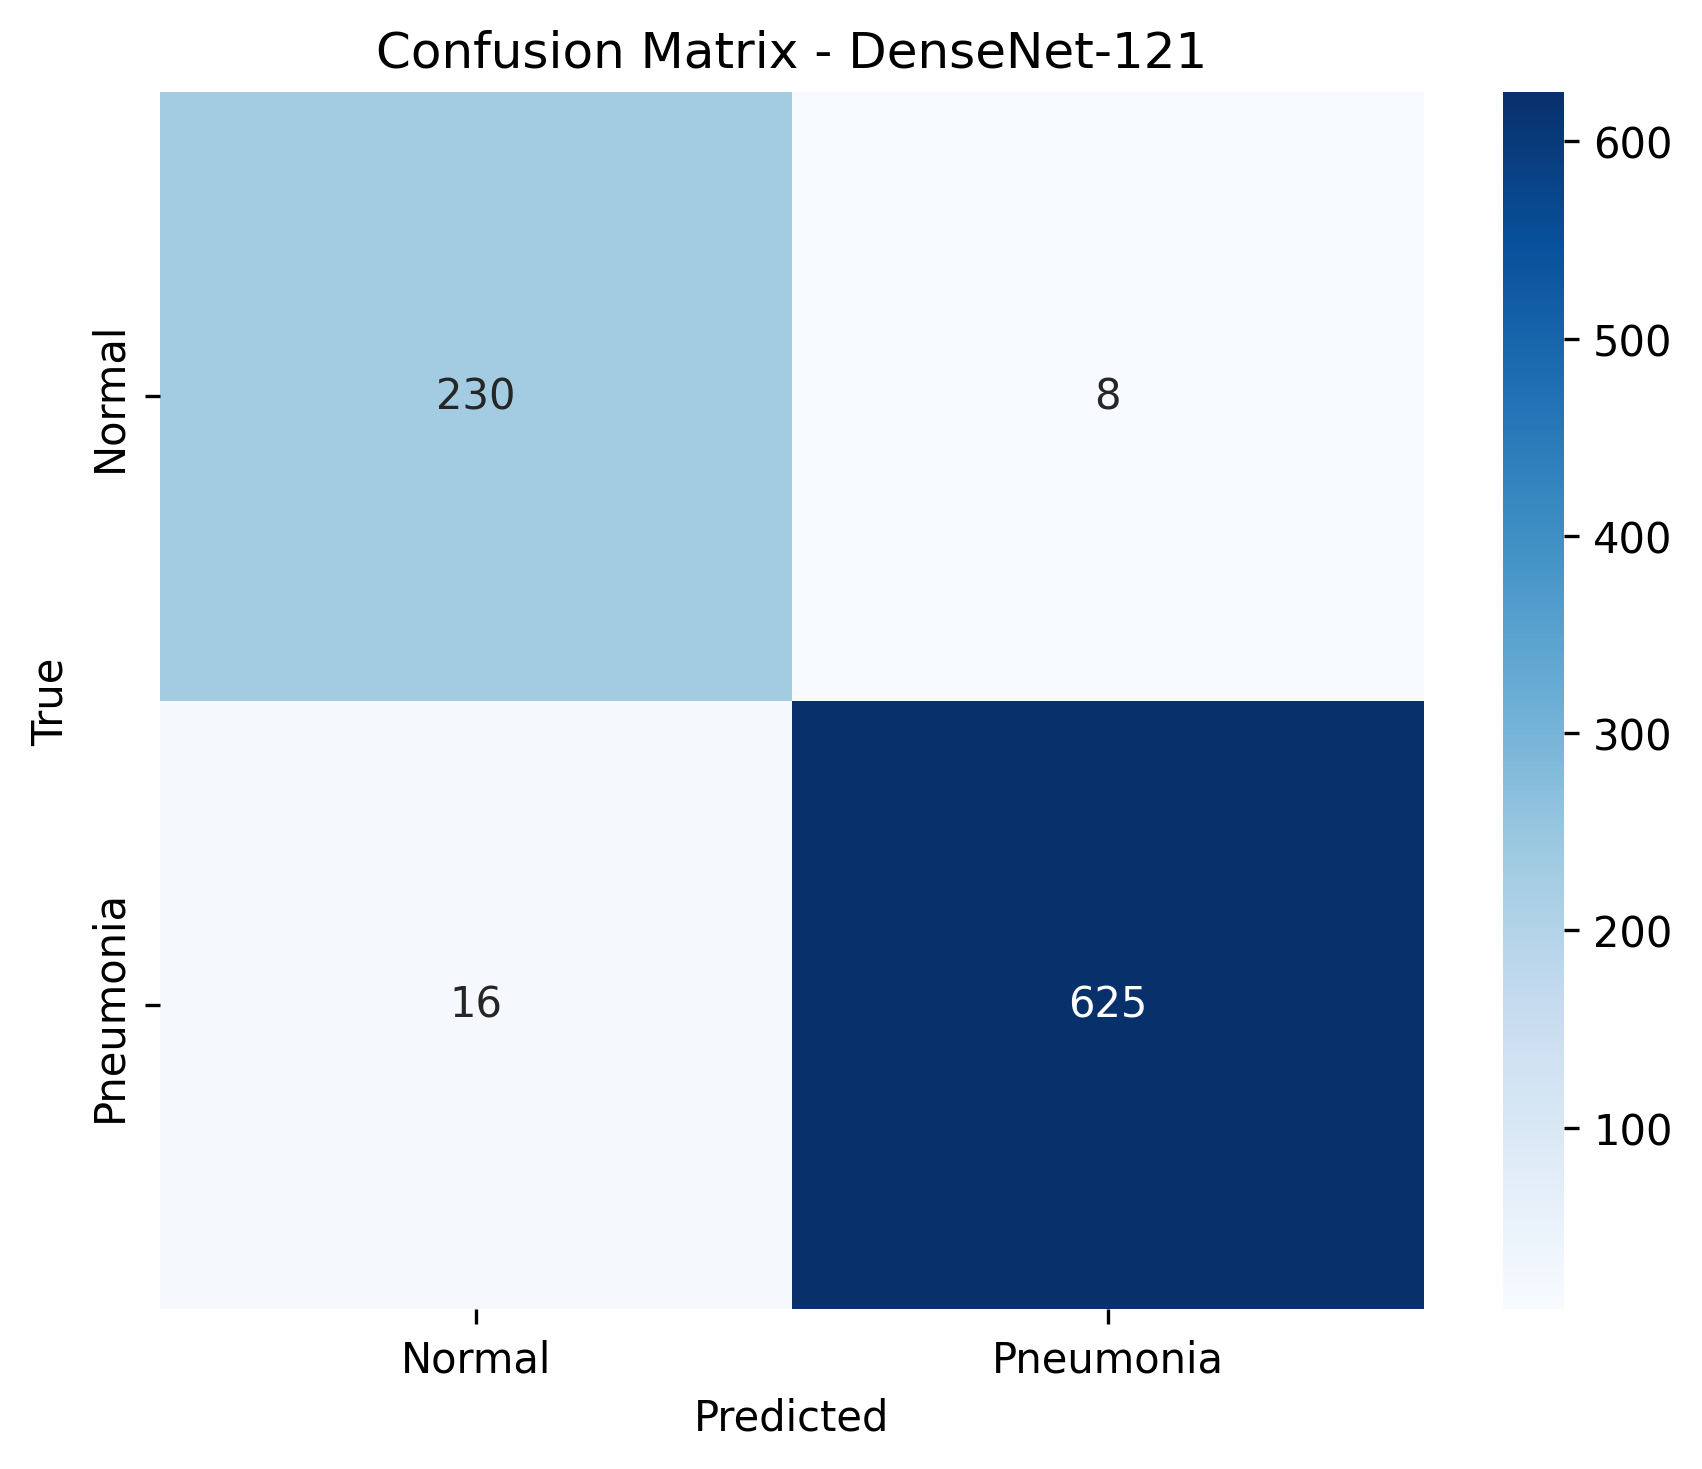

In [9]:
plt.figure(figsize=(6, 5))
sns.heatmap(
    densenet_results['confusion_matrix'],
    annot=True, fmt='d', cmap='Blues',
    xticklabels=['Normal', 'Pneumonia'],
    yticklabels=['Normal', 'Pneumonia']
)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - DenseNet-121')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig9_densenet_121_confusion_matrix.png'))
plt.show()

### 4.4 ROC Curve

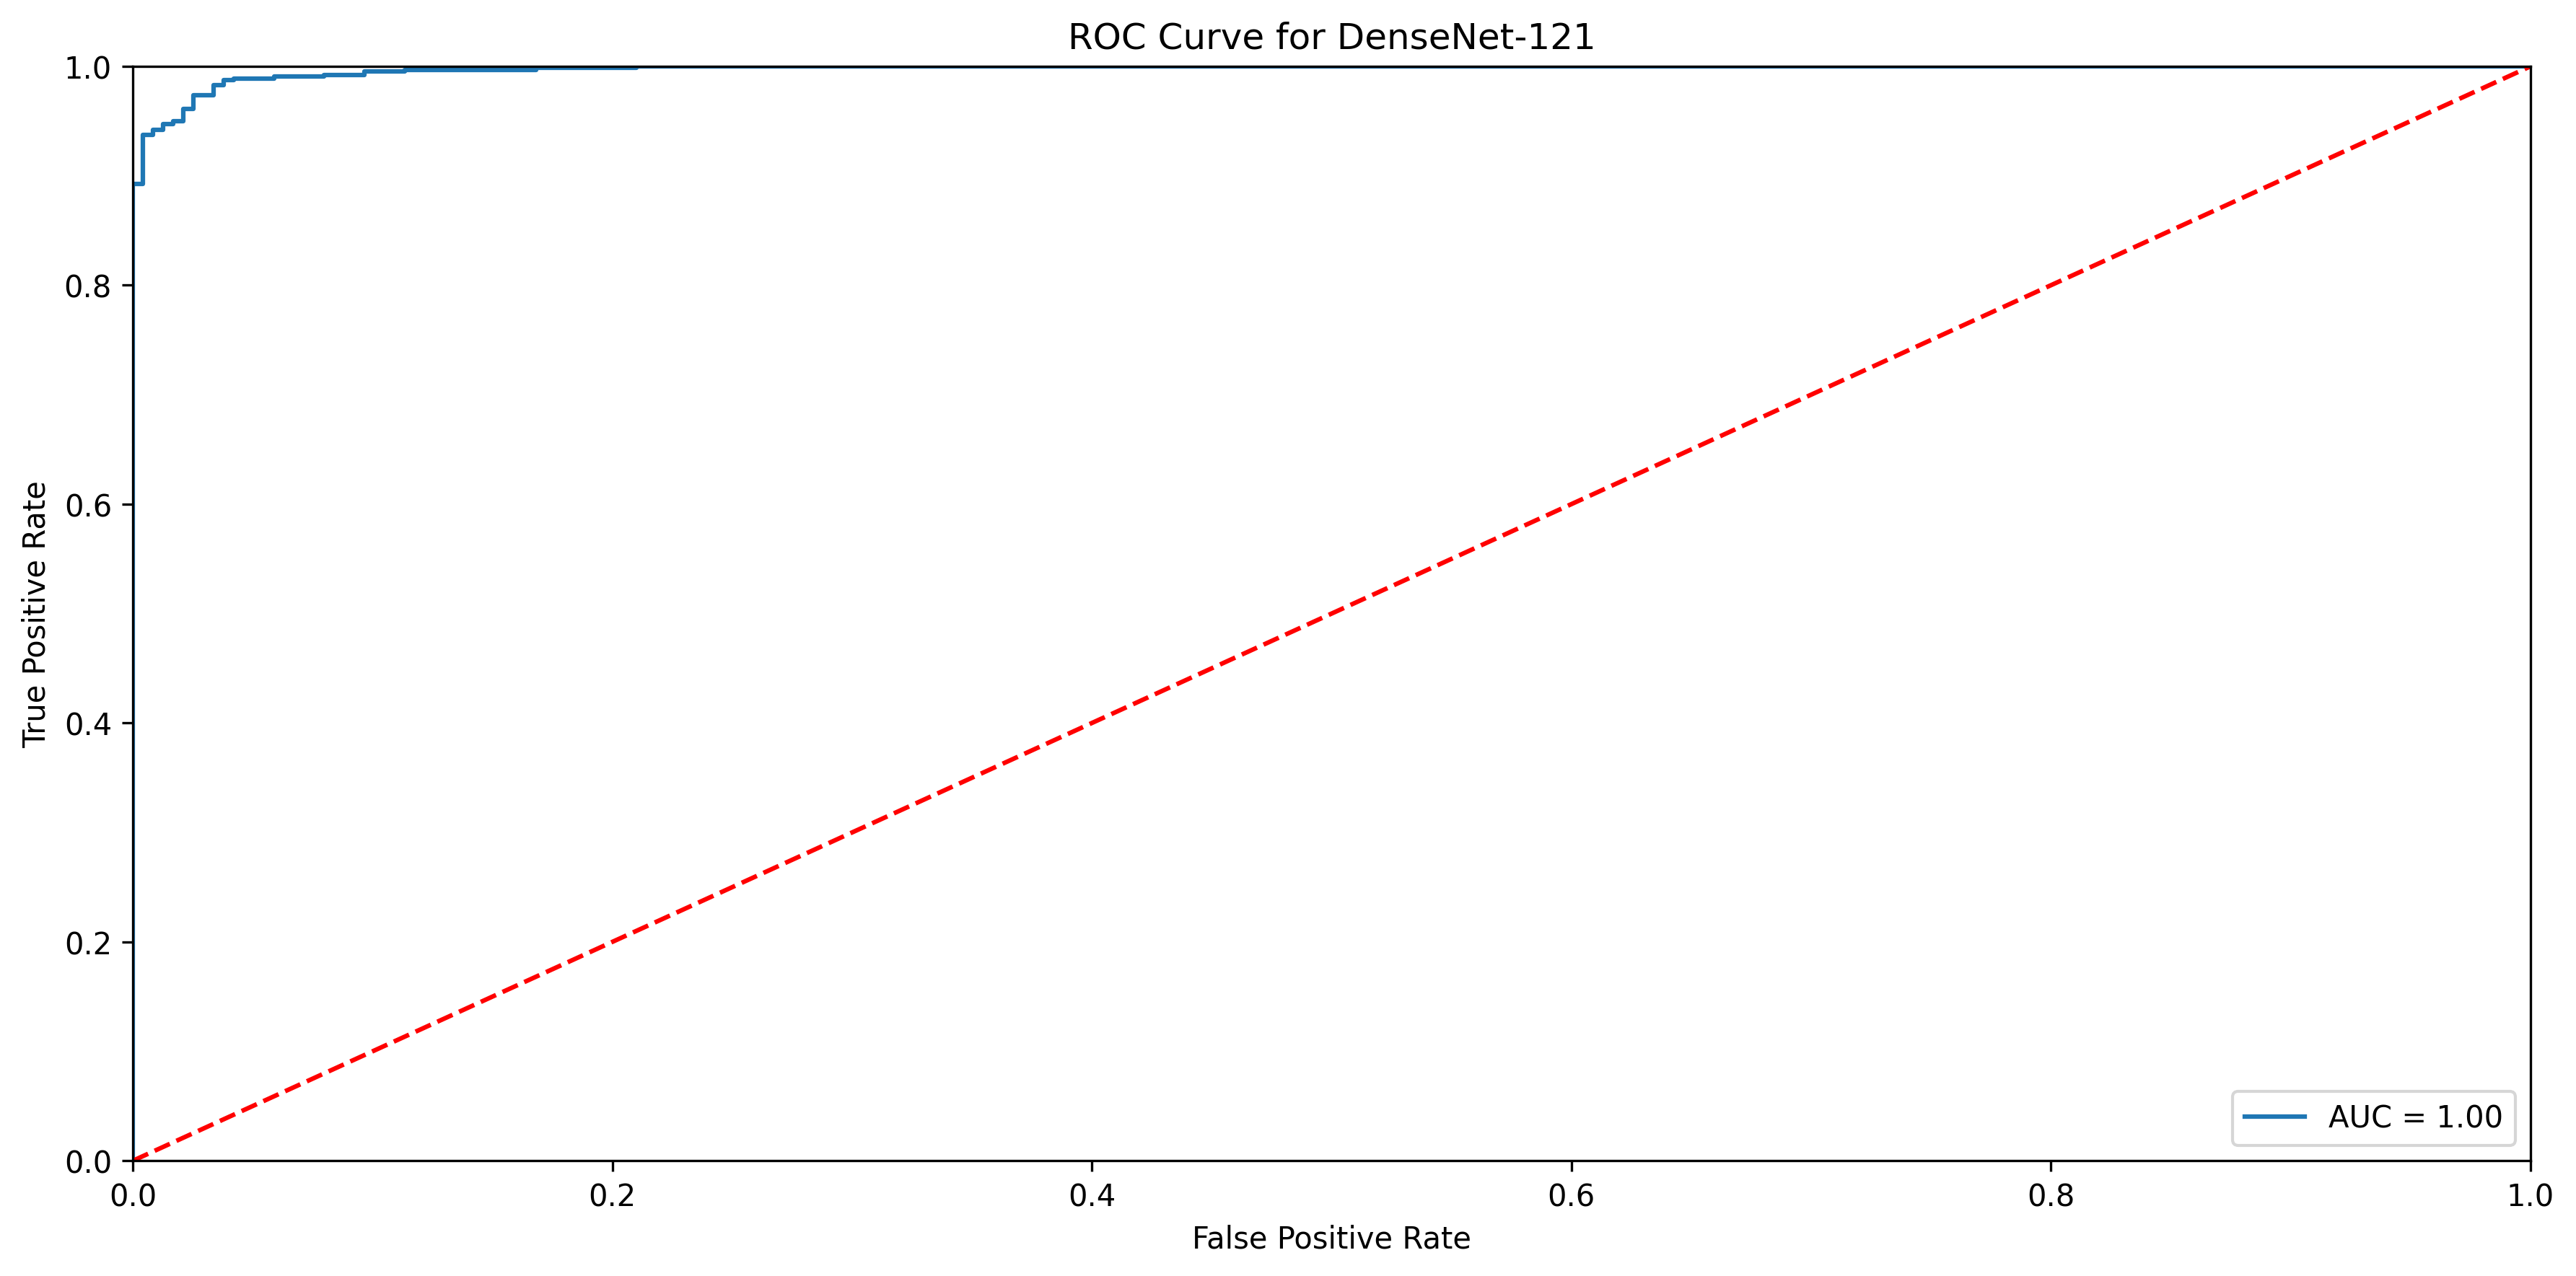

In [10]:
plt.figure(figsize=(12, 6))
plt.plot(
    densenet_results['fpr'], densenet_results['tpr'],
    label=f"AUC = {densenet_results['roc_auc']:.2f}"
)
plt.plot([0, 1], [0, 1], 'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for DenseNet-121')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig10_densenet_121_roc_curve.png'))
plt.show()

---

## 5. EfficientNet-B0 Evaluation

### 5.1 Load Checkpoint

In [11]:
model_efficientnet = get_model('efficientnet_b0').to(device)

checkpoint = torch.load(os.path.join(MODELS_DIR, 'efficientnet_b0.pth'), map_location=device)
model_efficientnet.load_state_dict(checkpoint['model_state_dict'])
model_efficientnet.eval()

print(f"Loaded EfficientNet-B0 | Best epoch: {checkpoint['epoch']} | Val loss: {checkpoint['val_loss']:.4f}")

Trainable: 3,700,169 / 4,008,829
Loaded EfficientNet-B0 | Best epoch: 9 | Val loss: 0.0330


### 5.2 Compute Metrics

In [12]:
efficientnet_results = evaluate(model=model_efficientnet, test_loader=test_loader, device=device)
print_results(efficientnet_results, 'EfficientNet-B0')


  EfficientNet-B0 Results
  Accuracy:  0.9670
  Precision: 0.9920
  Recall:    0.9626
  F1 Score:  0.9770
  AUC-ROC:   0.9969
  Confusion Matrix:
[[233   5]
 [ 24 617]]



### 5.3 Confusion Matrix

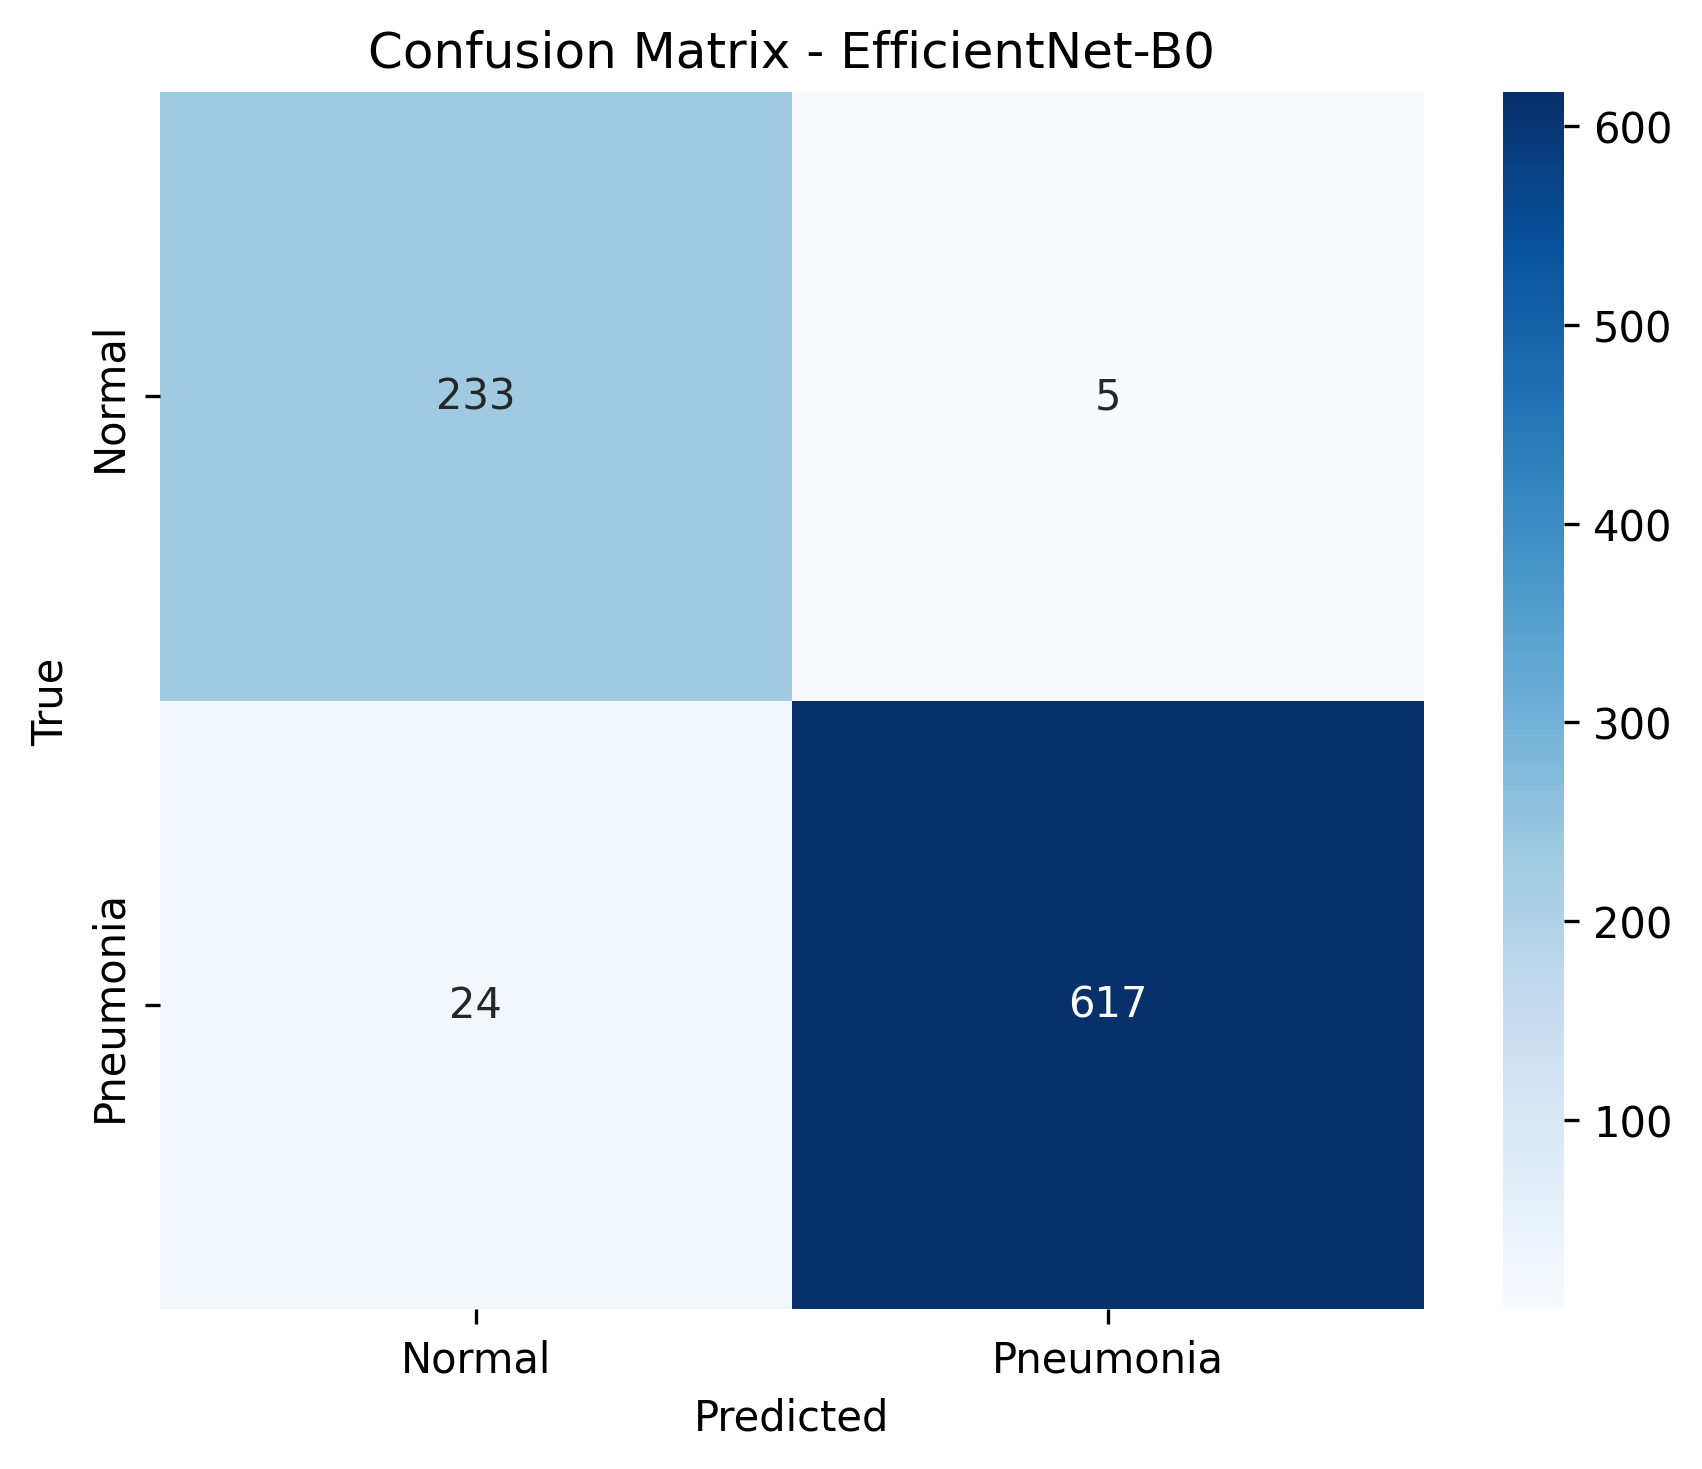

In [13]:
plt.figure(figsize=(6, 5))
sns.heatmap(
    efficientnet_results['confusion_matrix'],
    annot=True, fmt='d', cmap='Blues',
    xticklabels=['Normal', 'Pneumonia'],
    yticklabels=['Normal', 'Pneumonia']
)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - EfficientNet-B0')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig11_efficientnet_b0_confusion_matrix.png'))
plt.show()

### 5.4 ROC Curve

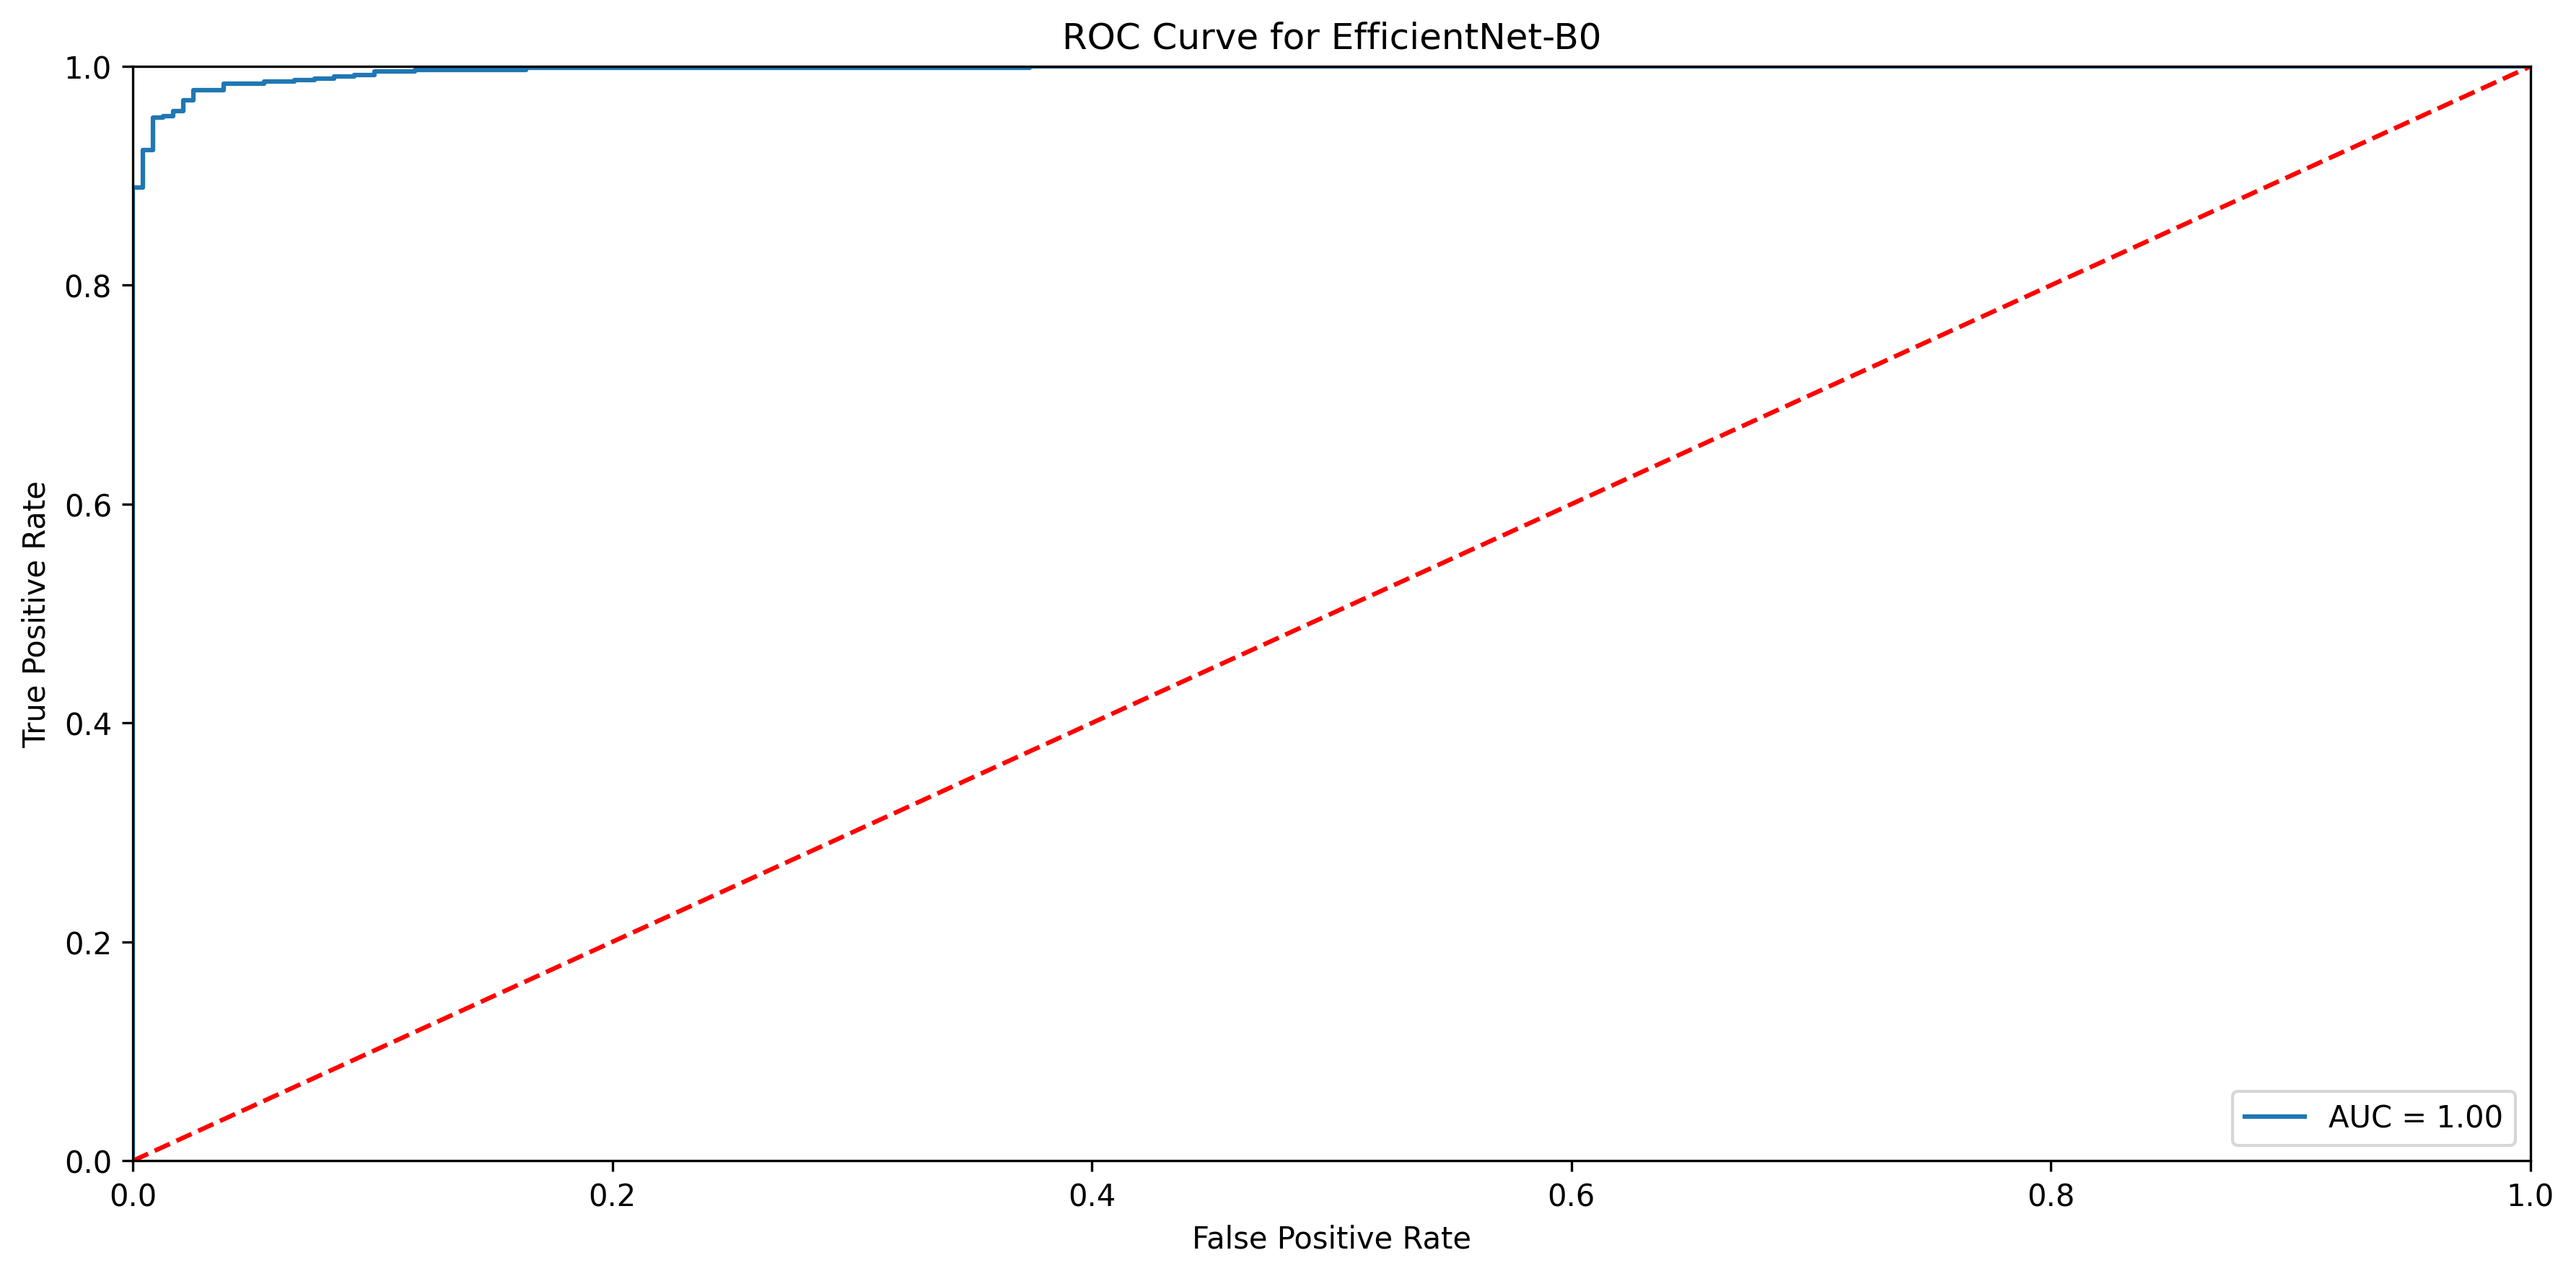

In [14]:
plt.figure(figsize=(12, 6))
plt.plot(
    efficientnet_results['fpr'], efficientnet_results['tpr'],
    label=f"AUC = {efficientnet_results['roc_auc']:.2f}"
)
plt.plot([0, 1], [0, 1], 'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for EfficientNet-B0')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig12_efficientnet_b0_roc_curve.png'))
plt.show()

---

## 6. Grad-CAM Visualisation

Grad-CAM generates a heatmap by computing the gradient of the predicted class score
with respect to the feature maps of a target convolutional layer. The resulting
heatmap highlights the spatial regions most influential to the model's prediction.

**Target layers:**
- ResNet-50: `layer4`
- DenseNet-121: `features.denseblock4`
- EfficientNet-B0: `features[8]`

### 6.1 Initialise GradCAM Objects

In [15]:
GradCAM_resnet       = GradCAM(model_resnet,       target_layer=model_resnet.layer4)
GradCAM_densenet     = GradCAM(model_densenet,     target_layer=model_densenet.features.denseblock4)
GradCAM_efficientnet = GradCAM(model_efficientnet, target_layer=model_efficientnet.features[8])

print("GradCAM hooks registered for all three models.")

GradCAM hooks registered for all three models.


### 6.2 Helper Function: Generate Grad-CAM Overlay

The low-resolution CAM (7x7 for ResNet-50/DenseNet-121) is upsampled to 224x224
using bilinear interpolation, mapped to a jet colourmap, and blended with the
original image at alpha=0.4.

In [16]:
def generate_gradcam(gradcam_obj, img_tensor, original_img, alpha=0.4):
    """
    Generate a Grad-CAM heatmap overlay for a single image.

    Parameters
    ----------
    gradcam_obj  : GradCAM
        Initialised GradCAM object with hooks attached to the target layer.
    img_tensor   : torch.Tensor
        Preprocessed input image tensor of shape (1, 3, 224, 224).
    original_img : PIL.Image
        Original image (224x224) for display and blending.
    alpha        : float
        Heatmap blending weight. Default is 0.4.

    Returns
    -------
    overlay : np.ndarray
        Blended image array of shape (224, 224, 3) with values in [0, 1].
    """
    # Generate raw CAM (low resolution, e.g. 7x7)
    cam = gradcam_obj.generate_heatmap(img_tensor, device=device)

    # Upsample to 224x224 using bilinear interpolation
    cam_resized = np.array(Image.fromarray(cam).resize((224, 224), Image.BILINEAR))

    # Apply jet colourmap and drop alpha channel
    heatmap_rgb = cm.jet(cam_resized)[:, :, :3]

    # Normalise original image to [0, 1]
    original_img_np = np.array(original_img) / 255.0

    # Blend heatmap with original image
    overlay = heatmap_rgb * alpha + original_img_np * (1 - alpha)

    return overlay

### 6.3 Sample Representative Test Images

Three representative samples are collected from the test set using DenseNet-121
predictions as the reference model:

- A correctly classified **Normal** image
- A correctly classified **Pneumonia** image
- A **misclassified** image (any error type)

In [17]:
sample_normal       = None
sample_pneumonia    = None
sample_misclassified = None

for idx in range(len(test_loader.dataset)):
    img_tensor, true_label = test_loader.dataset[idx]
    img_tensor   = img_tensor.unsqueeze(0).to(device)
    original_img = Image.open(test_loader.dataset.img_paths[idx]).convert('RGB').resize((224, 224))

    with torch.no_grad():
        output = model_densenet(img_tensor).squeeze()

    predicted = (output >= 0).long().item()

    if sample_normal is None and predicted == true_label and true_label == 0:
        sample_normal = (idx, img_tensor, original_img, true_label)

    if sample_pneumonia is None and predicted == true_label and true_label == 1:
        sample_pneumonia = (idx, img_tensor, original_img, true_label)

    if sample_misclassified is None and predicted != true_label:
        sample_misclassified = (idx, img_tensor, original_img, true_label)

    if all([sample_normal, sample_pneumonia, sample_misclassified]):
        break

print("Samples collected:")
print(f"  Normal       : index {sample_normal[0]}")
print(f"  Pneumonia    : index {sample_pneumonia[0]}")
print(f"  Misclassified: index {sample_misclassified[0]} (true label: {'Pneumonia' if sample_misclassified[3] == 1 else 'Normal'})")

Samples collected:
  Normal       : index 0
  Pneumonia    : index 238
  Misclassified: index 76 (true label: Normal)


### 6.4 Unpack Samples

In [18]:
_, normal_img_tensor,        normal_original_img,        _                      = sample_normal
_, pneumonia_img_tensor,     pneumonia_original_img,     _                      = sample_pneumonia
_, misclassified_img_tensor, misclassified_original_img, misclassified_true_label = sample_misclassified

true_label_name = 'Pneumonia' if misclassified_true_label == 1 else 'Normal'

### 6.5 Generate and Display 3x3 Grad-CAM Comparison Grid

Each row represents a case type; each column represents a model.
Warmer colours (red/yellow) indicate regions of higher activation.

d:\ATU\Deep Learning\Project\Pneumonia-Detection-Using-Deep-Learning\pneumonia_detection\Lib\site-packages\torch\nn\modules\module.py:1869: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)
d:\ATU\Deep Learning\Project\Pneumonia-Detection-Using-Deep-Learning\pneumonia_detection\Lib\site-packages\torch\autograd\graph.py:882: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\cuda\CublasHandlePool.cpp:410.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


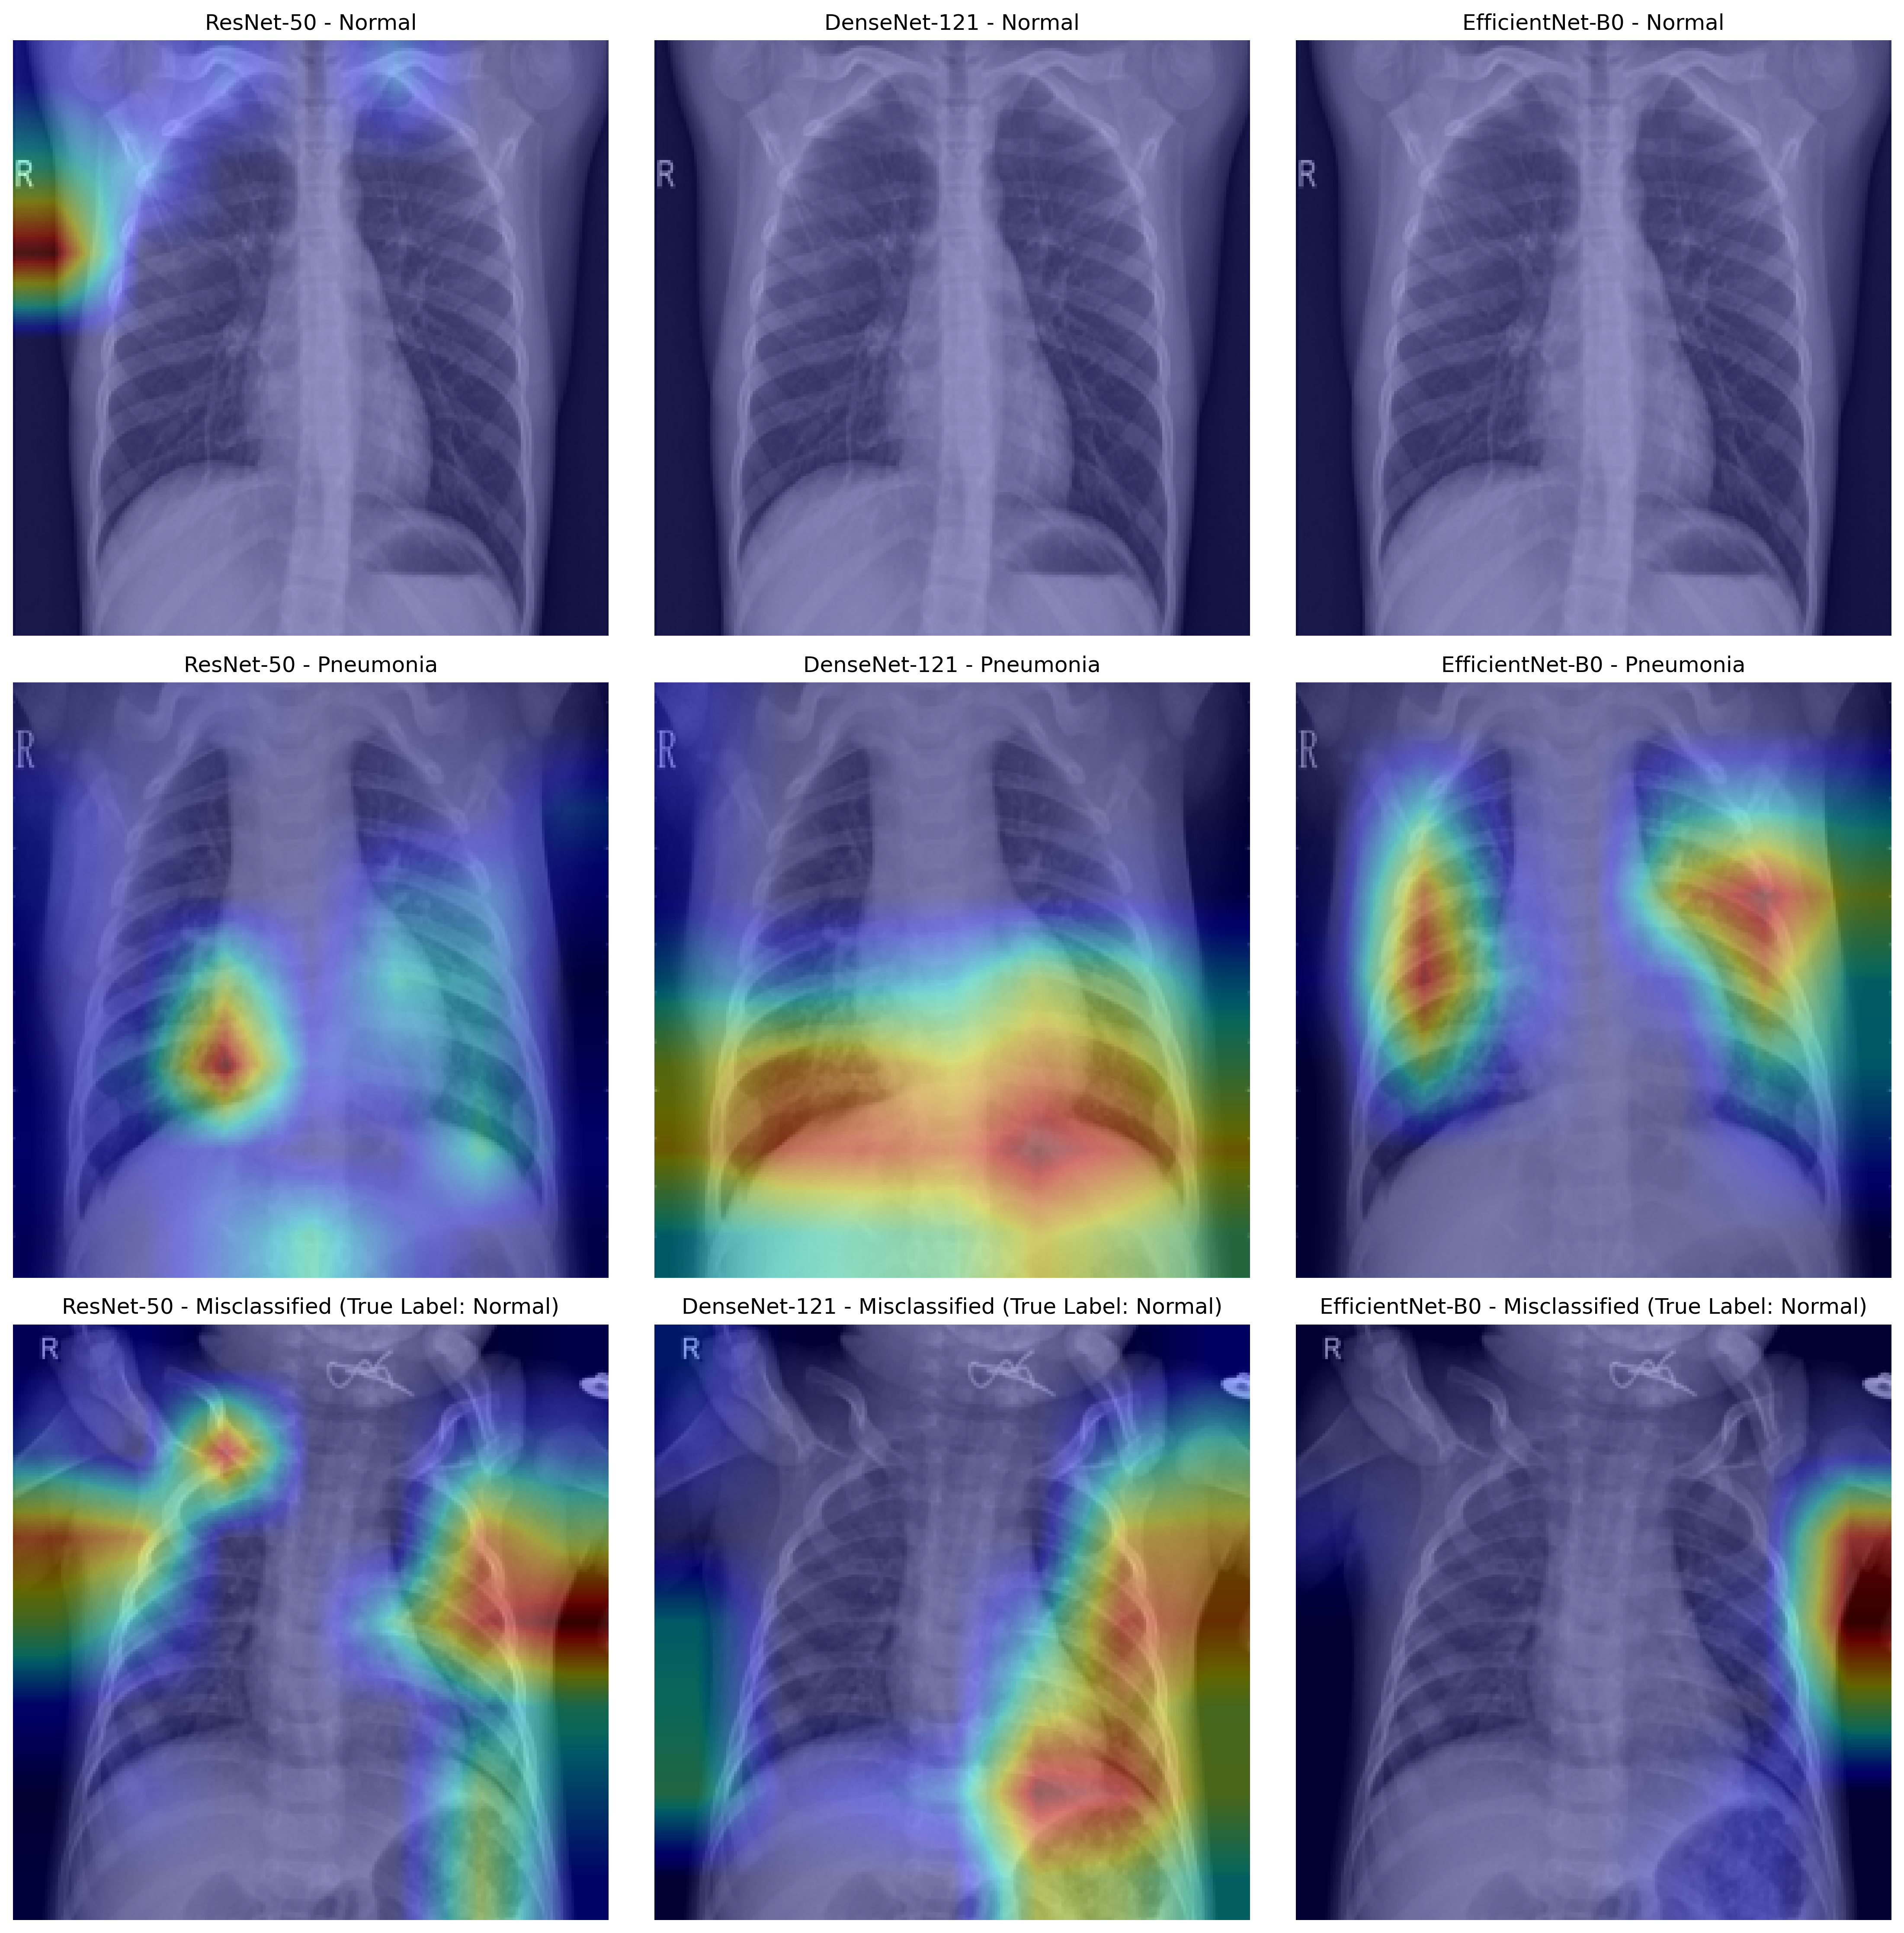

In [19]:
plt.figure(figsize=(15, 15))

# Row 1: Normal
plt.subplot(3, 3, 1)
plt.imshow(generate_gradcam(GradCAM_resnet,       normal_img_tensor, normal_original_img))
plt.axis('off')
plt.title('ResNet-50 - Normal')

plt.subplot(3, 3, 2)
plt.imshow(generate_gradcam(GradCAM_densenet,     normal_img_tensor, normal_original_img))
plt.axis('off')
plt.title('DenseNet-121 - Normal')

plt.subplot(3, 3, 3)
plt.imshow(generate_gradcam(GradCAM_efficientnet, normal_img_tensor, normal_original_img))
plt.axis('off')
plt.title('EfficientNet-B0 - Normal')

# Row 2: Pneumonia
plt.subplot(3, 3, 4)
plt.imshow(generate_gradcam(GradCAM_resnet,       pneumonia_img_tensor, pneumonia_original_img))
plt.axis('off')
plt.title('ResNet-50 - Pneumonia')

plt.subplot(3, 3, 5)
plt.imshow(generate_gradcam(GradCAM_densenet,     pneumonia_img_tensor, pneumonia_original_img))
plt.axis('off')
plt.title('DenseNet-121 - Pneumonia')

plt.subplot(3, 3, 6)
plt.imshow(generate_gradcam(GradCAM_efficientnet, pneumonia_img_tensor, pneumonia_original_img))
plt.axis('off')
plt.title('EfficientNet-B0 - Pneumonia')

# Row 3: Misclassified
plt.subplot(3, 3, 7)
plt.imshow(generate_gradcam(GradCAM_resnet,       misclassified_img_tensor, misclassified_original_img))
plt.axis('off')
plt.title(f'ResNet-50 - Misclassified (True Label: {true_label_name})')

plt.subplot(3, 3, 8)
plt.imshow(generate_gradcam(GradCAM_densenet,     misclassified_img_tensor, misclassified_original_img))
plt.axis('off')
plt.title(f'DenseNet-121 - Misclassified (True Label: {true_label_name})')

plt.subplot(3, 3, 9)
plt.imshow(generate_gradcam(GradCAM_efficientnet, misclassified_img_tensor, misclassified_original_img))
plt.axis('off')
plt.title(f'EfficientNet-B0 - Misclassified (True Label: {true_label_name})')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig13_gradcam_comparison.png'))
plt.show()

### 6.6 Remove Grad-CAM Hooks

Hooks must be removed after use to prevent unintended behaviour on subsequent
forward passes or re-runs of this notebook.

In [20]:
GradCAM_resnet.remove_hooks()
GradCAM_densenet.remove_hooks()
GradCAM_efficientnet.remove_hooks()

print("All Grad-CAM hooks removed successfully.")

All Grad-CAM hooks removed successfully.
